# NLP Preprocessing

Cleans, tokenizes, and lemmatizes the review text from `01_data_cleaning_and_eda.ipynb`, then explores the resulting vocabulary.

In [1]:
import re
import string
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

sns.set_style("whitegrid")

for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

PROCESSED_DIR = Path("datasets/processed")
FINAL_DIR = Path("datasets/final")
FINAL_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "clean_reviews.csv")
df = df.dropna(subset=["review"]).reset_index(drop=True)
print(f"Loaded {df.shape[0]} rows")
df["sentiment"].value_counts()

Loaded 10000 rows


sentiment
Positive    6863
Negative    1676
Neutral     1461
Name: count, dtype: int64

## Text Cleaning

Lowercase, strip HTML/URLs/emails/numbers/punctuation/emoji, then collapse whitespace.

In [3]:
EMOJI_PATTERN = re.compile(
    "[\U0001F300-\U0001FAFF\U00002600-\U000027BF]+", flags=re.UNICODE
)

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)                    # HTML tags
    text = re.sub(r"(https?://\S+|www\.\S+)", " ", text)  # URLs
    text = re.sub(r"\S+@\S+\.\S+", " ", text)             # emails
    text = EMOJI_PATTERN.sub(" ", text)
    text = re.sub(r"\d+", " ", text)                       # numbers
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)             # e.g. "soooo" -> "soo"
    return re.sub(r"\s+", " ", text).strip()

df["clean_review"] = df["review"].astype(str).apply(clean_text)
df = df[df["clean_review"] != ""].reset_index(drop=True)
df[["review", "clean_review"]].head()

,review,clean_review
0,My wife took me here on my birthday for breakf...,my wife took me here on my birthday for breakf...
1,I have no idea why some people give bad review...,i have no idea why some people give bad review...
2,love the gyro plate. Rice is so good and I als...,love the gyro plate rice is so good and i also...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",rosie dakota and i love chaparral dog park its...
4,General Manager Scott Petello is a good egg!!!...,general manager scott petello is a good egg no...


## Tokenize, Remove Stopwords, Lemmatize

In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> list:
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    return [lemmatizer.lemmatize(w) for w in tokens]

df["tokens"] = df["clean_review"].apply(preprocess)
df["processed_review"] = df["tokens"].str.join(" ")
df[["review", "clean_review", "processed_review"]].head()

,review,clean_review,processed_review
0,My wife took me here on my birthday for breakf...,my wife took me here on my birthday for breakf...,wife took birthday breakfast excellent weather...
1,I have no idea why some people give bad review...,i have no idea why some people give bad review...,idea people give bad review place go show plea...
2,love the gyro plate. Rice is so good and I als...,love the gyro plate rice is so good and i also...,love gyro plate rice good also dig candy selec...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",rosie dakota and i love chaparral dog park its...,rosie dakota love chaparral dog park convenien...
4,General Manager Scott Petello is a good egg!!!...,general manager scott petello is a good egg no...,general manager scott petello good egg go deta...


In [5]:
# Spot-check a few rows end to end
for _, row in df.sample(5, random_state=42).iterrows():
    print(f"Original : {row['review']}")
    print(f"Processed: {row['processed_review']}")
    print("-" * 80)

Original : We got here around midnight last Friday... the place was dead. However, they were still serving food and we enjoyed some well made pub grub. Service was friendly, quality cocktails were served, and the atmosphere is derived from an old Uno's, which certainly works for a sports bar. It being located in a somewhat commercial area, I can see why it's empty so late on a Friday. From what my friends tell me - this is a great spot for happy hour, and it stays relatively busy thru 10pm.

*UPDATE - Great patio for day-drinking on the weekends!
Processed: got around midnight last friday place dead however still serving food enjoyed well made pub grub service friendly quality cocktail served atmosphere derived old unos certainly work sport bar located somewhat commercial area see empty late friday friend tell great spot happy hour stay relatively busy thru pm update great patio daydrinking weekend
--------------------------------------------------------------------------------
Origina

## Text Statistics

In [6]:
df["character_count"] = df["processed_review"].str.len()
df["sentence_count"] = df["review"].astype(str).apply(lambda t: len(sent_tokenize(t)))
df["average_word_length"] = df["tokens"].apply(
    lambda words: round(sum(len(w) for w in words) / len(words), 2) if words else 0.0
)
df[["character_count", "sentence_count", "average_word_length"]].describe()

,character_count,sentence_count,average_word_length
count,10000.000000,10000.000000,10000.000000
mean,432.774500,9.212600,5.509157
std,375.236608,7.299173,0.492560
min,1.000000,1.000000,1.000000
25%,180.000000,4.000000,5.220000
50%,328.500000,7.000000,5.490000
75%,566.000000,12.000000,5.770000
max,3438.000000,92.000000,10.500000


## Vocabulary Visualizations

C:\Users\PUSHTI TILVA\AppData\Local\Temp\ipykernel_15156\883904782.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words, x="count", y="word", palette="viridis")


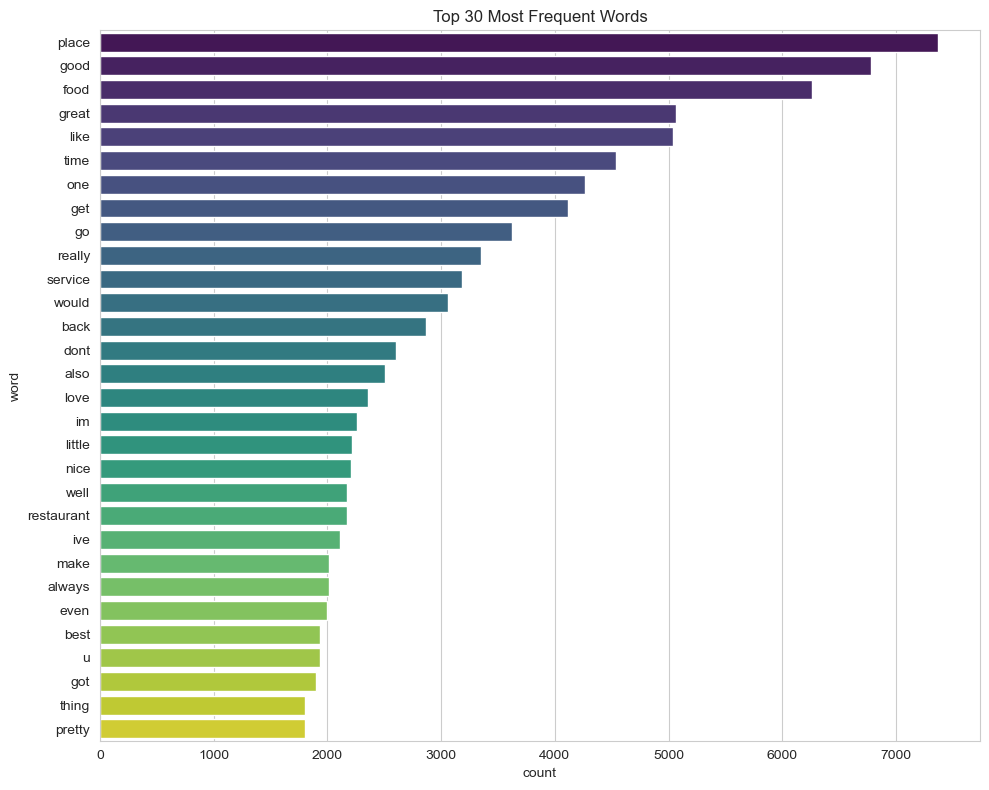

In [7]:
# Top 30 most frequent words
word_freq = Counter(word for tokens in df["tokens"] for word in tokens)
top_words = pd.DataFrame(word_freq.most_common(30), columns=["word", "count"])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_words, x="count", y="word", palette="viridis")
plt.title("Top 30 Most Frequent Words")
plt.tight_layout()
plt.show()

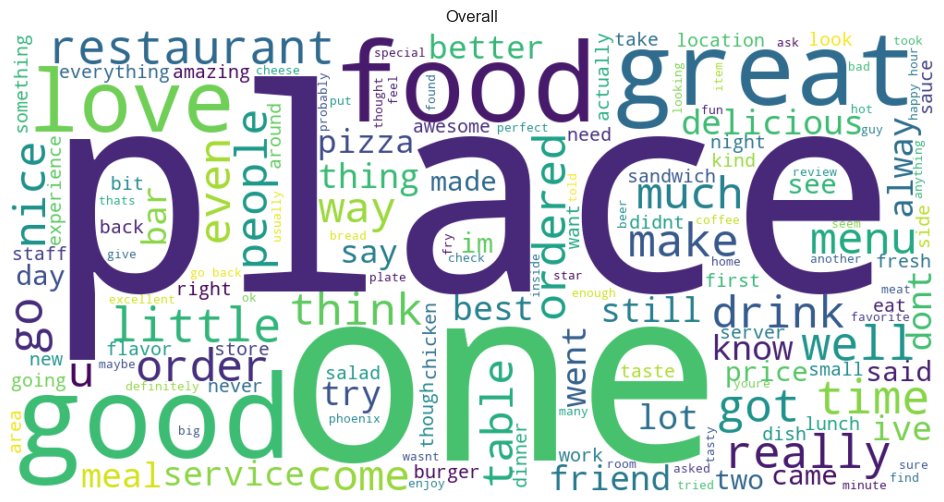

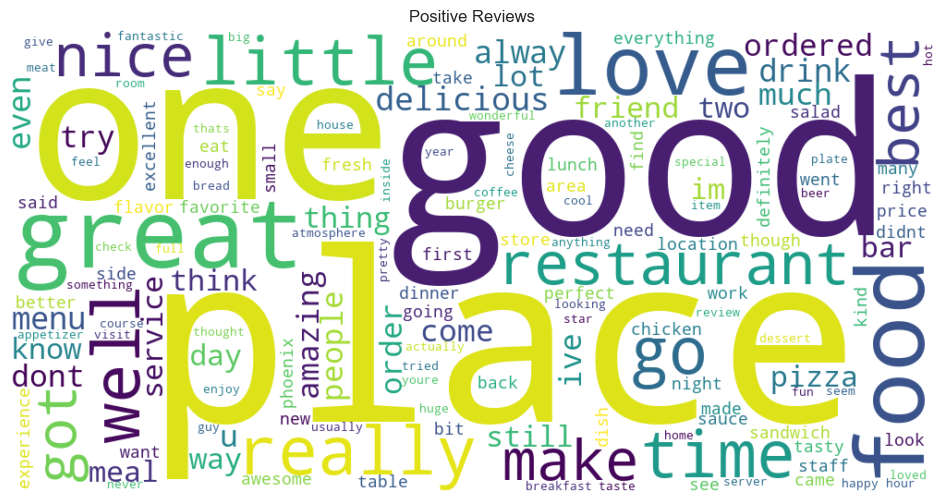

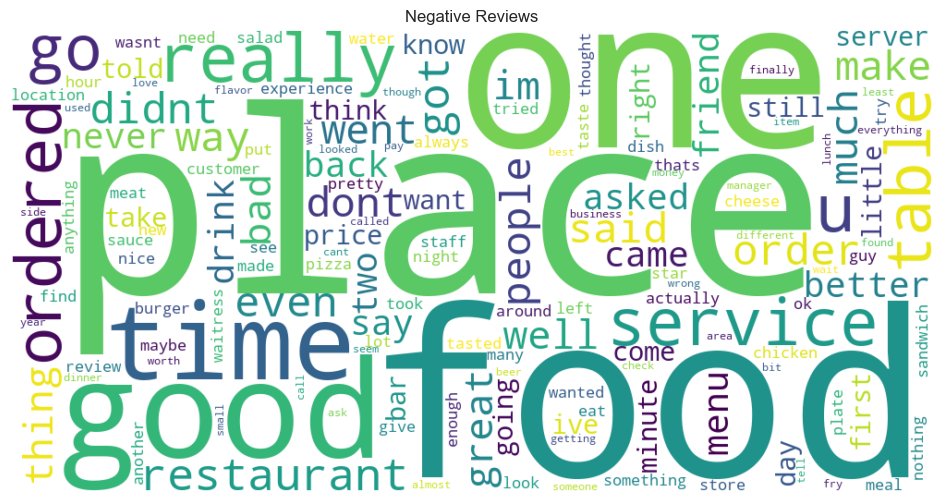

In [8]:
def show_wordcloud(text: str, title: str):
    wc = WordCloud(width=1000, height=500, background_color="white", max_words=150).generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

show_wordcloud(" ".join(df["processed_review"]), "Overall")
show_wordcloud(" ".join(df.loc[df["sentiment"] == "Positive", "processed_review"]), "Positive Reviews")
show_wordcloud(" ".join(df.loc[df["sentiment"] == "Negative", "processed_review"]), "Negative Reviews")

C:\Users\PUSHTI TILVA\AppData\Local\Temp\ipykernel_15156\2697735137.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, x="count", y=top_df.columns[0], palette="crest")


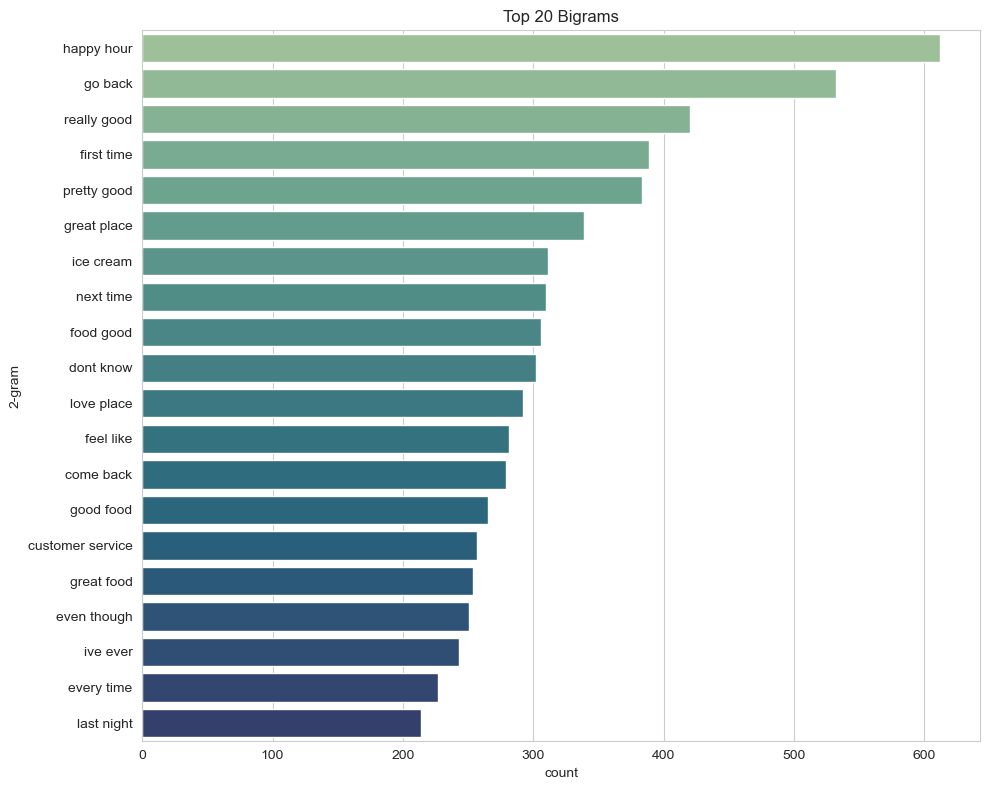

C:\Users\PUSHTI TILVA\AppData\Local\Temp\ipykernel_15156\2697735137.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, x="count", y=top_df.columns[0], palette="crest")


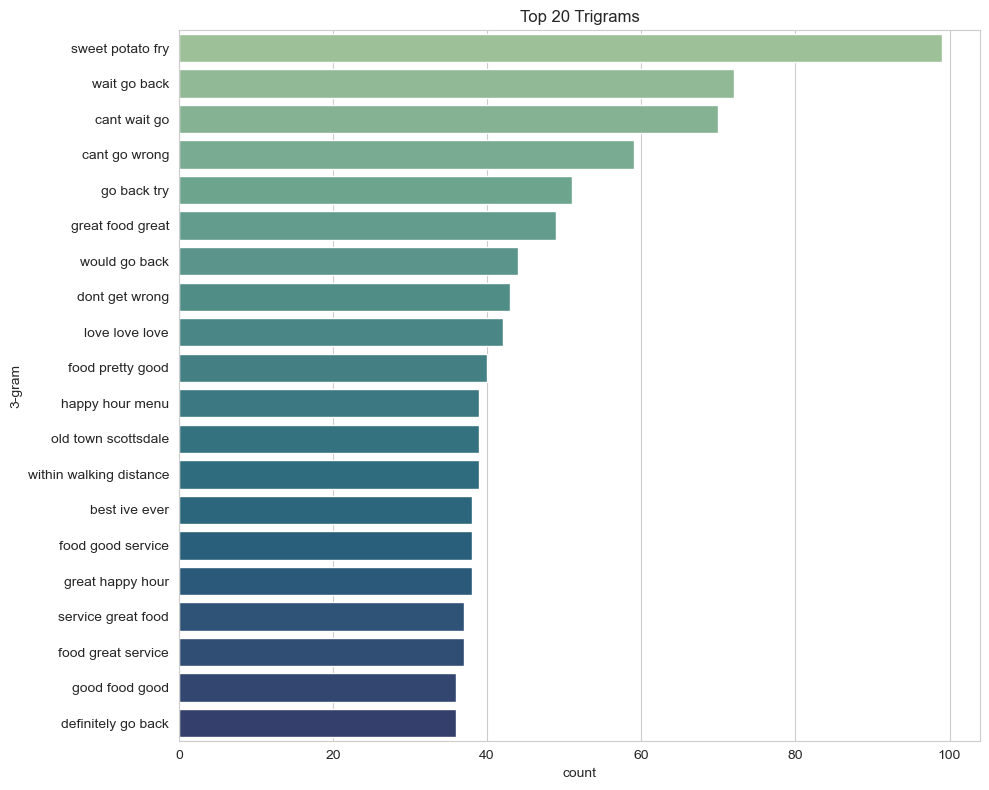

In [9]:
def top_ngrams(tokens_col, n, top_n=20):
    counts = Counter()
    for tokens in tokens_col:
        counts.update(" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1))
    return pd.DataFrame(counts.most_common(top_n), columns=[f"{n}-gram", "count"])

for n, label in [(2, "Bigrams"), (3, "Trigrams")]:
    top_df = top_ngrams(df["tokens"], n)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_df, x="count", y=top_df.columns[0], palette="crest")
    plt.title(f"Top 20 {label}")
    plt.tight_layout()
    plt.show()

## Save Final Dataset

In [10]:
final_columns = [
    "review", "processed_review", "stars", "sentiment",
    "review_length", "word_count", "character_count",
    "sentence_count", "average_word_length",
]

output_file = FINAL_DIR / "final_reviews.csv"
df[final_columns].to_csv(output_file, index=False)
print(f"Saved {df.shape[0]} rows to {output_file}")

Saved 10000 rows to datasets\final\final_reviews.csv
